# CBIS notebook

In [1]:
!pip install -q kaggle

%cd /content
!kaggle datasets download -d awsaf49/cbis-ddsm-breast-cancer-image-dataset -p /content/cbis

!unzip /content/cbis/cbis-ddsm-breast-cancer-image-dataset.zip -d /content/cbis

Le flux de sortie a été tronqué et ne contient que les 5000 dernières lignes.
  inflating: /content/cbis/jpeg/1.3.6.1.4.1.9590.100.1.2.295326067813319071803507885093865003464/1-076.jpg  
  inflating: /content/cbis/jpeg/1.3.6.1.4.1.9590.100.1.2.295334798611650724727702371150477767947/1-265.jpg  
  inflating: /content/cbis/jpeg/1.3.6.1.4.1.9590.100.1.2.295334798611650724727702371150477767947/2-266.jpg  
  inflating: /content/cbis/jpeg/1.3.6.1.4.1.9590.100.1.2.295360926313492745441868049270168300162/1-067.jpg  
  inflating: /content/cbis/jpeg/1.3.6.1.4.1.9590.100.1.2.295394441612082321922200964343746626621/1-002.jpg  
  inflating: /content/cbis/jpeg/1.3.6.1.4.1.9590.100.1.2.295397487412067903910787953980192002590/1-233.jpg  
  inflating: /content/cbis/jpeg/1.3.6.1.4.1.9590.100.1.2.295400289412664594307776853882592114725/1-294.jpg  
  inflating: /content/cbis/jpeg/1.3.6.1.4.1.9590.100.1.2.295400289412664594307776853882592114725/2-223.jpg  
  inflating: /content/cbis/jpeg/1.3.6.1.4.1.9590.1

## 1. Imports et configuration

Cette section contient seulement les dépendances et les chemins globaux.


In [22]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.utils.data import WeightedRandomSampler

from tqdm.notebook import tqdm

from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

try:
    import torchvision.transforms as T
except ImportError:
    T = None

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device =', DEVICE)

IMAGES_ROOT = Path('cbis/jpeg')
CSV_PATH = Path('cbis/csv/mass_case_description_train_set.csv')


device = cuda


## 2. Lecture du CSV

In [3]:
df = pd.read_csv(CSV_PATH)
print(df.shape)
df.head()


(1318, 14)


,patient_id,breast_density,left or right breast,image view,abnormality id,abnormality type,mass shape,mass margins,assessment,pathology,subtlety,image file path,cropped image file path,ROI mask file path
0,P_00001,3,LEFT,CC,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4,Mass-Training_P_00001_LEFT_CC/1.3.6.1.4.1.9590...,Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.95...,Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.95...
1,P_00001,3,LEFT,MLO,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4,Mass-Training_P_00001_LEFT_MLO/1.3.6.1.4.1.959...,Mass-Training_P_00001_LEFT_MLO_1/1.3.6.1.4.1.9...,Mass-Training_P_00001_LEFT_MLO_1/1.3.6.1.4.1.9...
2,P_00004,3,LEFT,CC,1,mass,ARCHITECTURAL_DISTORTION,ILL_DEFINED,4,BENIGN,3,Mass-Training_P_00004_LEFT_CC/1.3.6.1.4.1.9590...,Mass-Training_P_00004_LEFT_CC_1/1.3.6.1.4.1.95...,Mass-Training_P_00004_LEFT_CC_1/1.3.6.1.4.1.95...
3,P_00004,3,LEFT,MLO,1,mass,ARCHITECTURAL_DISTORTION,ILL_DEFINED,4,BENIGN,3,Mass-Training_P_00004_LEFT_MLO/1.3.6.1.4.1.959...,Mass-Training_P_00004_LEFT_MLO_1/1.3.6.1.4.1.9...,Mass-Training_P_00004_LEFT_MLO_1/1.3.6.1.4.1.9...
4,P_00004,3,RIGHT,MLO,1,mass,OVAL,CIRCUMSCRIBED,4,BENIGN,5,Mass-Training_P_00004_RIGHT_MLO/1.3.6.1.4.1.95...,Mass-Training_P_00004_RIGHT_MLO_1/1.3.6.1.4.1....,Mass-Training_P_00004_RIGHT_MLO_1/1.3.6.1.4.1....


In [4]:
PATH_COL = 'image file path'
LABEL_COL = 'pathology'

assert PATH_COL in df.columns, f"Colonne manquante: {PATH_COL}"
assert LABEL_COL in df.columns, f"Colonne manquante: {LABEL_COL}"

print(df[[PATH_COL, LABEL_COL]].head())


                                     image file path  pathology
0  Mass-Training_P_00001_LEFT_CC/1.3.6.1.4.1.9590...  MALIGNANT
1  Mass-Training_P_00001_LEFT_MLO/1.3.6.1.4.1.959...  MALIGNANT
2  Mass-Training_P_00004_LEFT_CC/1.3.6.1.4.1.9590...     BENIGN
3  Mass-Training_P_00004_LEFT_MLO/1.3.6.1.4.1.959...     BENIGN
4  Mass-Training_P_00004_RIGHT_MLO/1.3.6.1.4.1.95...     BENIGN


## 3. Construire une table légère

In [ ]:
df = pd.read_csv(CSV_PATH).copy()

df['label'] = df['pathology'].map({
    'BENIGN': 0,
    'BENIGN_WITHOUT_CALLBACK': 0,
    'MALIGNANT': 1
})

df = df.dropna(subset=['label']).copy()
df['label'] = df['label'].astype(int)

def csv_path_to_jpg_folder(csv_path_str):
    parts = str(csv_path_str).split('/')
    if len(parts) < 3:
        return None
    return IMAGES_ROOT / parts[2]

def first_jpg_in_folder(folder):
    if folder is None or not Path(folder).exists():
        return None
    files = sorted([f for f in os.listdir(folder) if f.lower().endswith('.jpg')])
    if not files:
        return None
    return str(Path(folder) / files[0])

df['image_folder'] = df['image file path'].apply(csv_path_to_jpg_folder)
df['image_path'] = df['image_folder'].apply(first_jpg_in_folder)

meta_df = df.dropna(subset=['image_path']).copy()

print(meta_df.shape)
display(meta_df[['image file path', 'image_path', 'label']].head())
print(meta_df['label'].value_counts())

(1318, 17)


,image file path,image_path,label
0,Mass-Training_P_00001_LEFT_CC/1.3.6.1.4.1.9590...,cbis/jpeg/1.3.6.1.4.1.9590.100.1.2.34238619481...,1
1,Mass-Training_P_00001_LEFT_MLO/1.3.6.1.4.1.959...,cbis/jpeg/1.3.6.1.4.1.9590.100.1.2.35930832931...,1
2,Mass-Training_P_00004_LEFT_CC/1.3.6.1.4.1.9590...,cbis/jpeg/1.3.6.1.4.1.9590.100.1.2.89180046211...,0
3,Mass-Training_P_00004_LEFT_MLO/1.3.6.1.4.1.959...,cbis/jpeg/1.3.6.1.4.1.9590.100.1.2.29536092631...,0
4,Mass-Training_P_00004_RIGHT_MLO/1.3.6.1.4.1.95...,cbis/jpeg/1.3.6.1.4.1.9590.100.1.2.41052475491...,0


label
0    681
1    637
Name: count, dtype: int64


In [6]:
meta_df['label'].value_counts()


,count
label,
0,681
1,637


## 4. Split train / validation rapide

On garde un petit sous-ensemble pour tester vite, puis on pourra agrandir plus tard.


In [7]:
def stratified_split(df, label_col='label', train_frac=0.8, seed=SEED):
    train_parts = []
    val_parts = []
    for label, group in df.groupby(label_col):
        group = group.sample(frac=1.0, random_state=seed).reset_index(drop=True)
        cut = int(len(group) * train_frac)
        train_parts.append(group.iloc[:cut])
        val_parts.append(group.iloc[cut:])
    train_df = pd.concat(train_parts).sample(frac=1.0, random_state=seed).reset_index(drop=True)
    val_df = pd.concat(val_parts).sample(frac=1.0, random_state=seed).reset_index(drop=True)
    return train_df, val_df

train_df, val_df = stratified_split(meta_df)
print('train:', train_df.shape, 'val:', val_df.shape)


train: (1053, 17) val: (265, 17)


In [8]:
FAST_MODE = True
FAST_TRAIN_SAMPLES = 512
FAST_VAL_SAMPLES = 128

if FAST_MODE:
    train_df = train_df.groupby('label', group_keys=False).head(FAST_TRAIN_SAMPLES // 2).reset_index(drop=True)
    val_df = val_df.groupby('label', group_keys=False).head(FAST_VAL_SAMPLES // 2).reset_index(drop=True)

print('train used:', train_df.shape)
print('val used:', val_df.shape)


train used: (512, 17)
val used: (128, 17)


## 5. Transformations

On réduit la taille d'image pour accélérer.
`128x128` est bien plus léger que `224x224` pour des essais.


In [9]:
if T is not None:
    train_transform = T.Compose([
        T.Resize((128, 128)),
        T.Grayscale(num_output_channels=1),
        T.ToTensor(),
    ])
    val_transform = T.Compose([
        T.Resize((128, 128)),
        T.Grayscale(num_output_channels=1),
        T.ToTensor(),
    ])
else:
    train_transform = None
    val_transform = None


## 6. Dataset propre

In [10]:
class CBISDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image = Image.open(row['image_path']).convert('RGB')

        if self.transform is not None:
            image = self.transform(image)
        else:
            image = image.resize((128, 128))
            image = torch.from_numpy(np.array(image)).permute(2, 0, 1).float() / 255.0

        label = torch.tensor(row['label'], dtype=torch.float32)
        return image, label


## 7. DataLoaders


In [ ]:
BATCH_SIZE = 32
NUM_WORKERS = 0

# Dataset
train_dataset = CBISDataset(train_df, transform=train_transform)
val_dataset = CBISDataset(val_df, transform=val_transform)

class_counts = train_df['label'].value_counts().sort_index()
print("Class counts:")
print(class_counts)

class_weights = 1.0 / class_counts
print("\nClass weights:")
print(class_weights)

sample_weights = train_df['label'].map(class_weights).values
sample_weights = torch.DoubleTensor(sample_weights)

train_sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

# DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    sampler=train_sampler,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)

len(train_dataset), len(val_dataset)


Class counts:
label
0    256
1    256
Name: count, dtype: int64

Class weights:
label
0    0.003906
1    0.003906
Name: count, dtype: float64


(512, 128)

In [12]:
images, labels = next(iter(train_loader))
print(images.shape, labels.shape)


torch.Size([32, 1, 128, 128]) torch.Size([32])


## 8. Modèle simple

Le flatten dépend maintenant de `128x128`.
Après deux max-pool, on obtient `32 x 32 x 32`.


In [18]:
class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 32 * 32, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x.squeeze(1)

criterion = nn.BCEWithLogitsLoss()
model = Model().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
model


Model(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=32768, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=1, bias=True)
  )
)

## 9. Boucles train / eval


In [16]:
def run_epoch(model, loader, criterion, optimizer=None, device=DEVICE, desc="Train"):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    batch_bar = tqdm(loader, desc=desc, unit="batch", leave=False)

    for images, labels in batch_bar:
        images = images.to(device)
        labels = labels.to(device)

        with torch.set_grad_enabled(is_train):
            logits = model(images)
            loss = criterion(logits, labels)
            probs = torch.sigmoid(logits)
            preds = (probs >= 0.5).float()

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        total_correct += (preds == labels).sum().item()
        total_samples += batch_size

        batch_bar.set_postfix(
            loss=f"{total_loss / total_samples:.4f}",
            acc=f"{total_correct / total_samples:.4f}"
        )

    return total_loss / total_samples, total_correct / total_samples

In [19]:
EPOCHS = 10
history = []

for epoch in range(EPOCHS):
    train_loss, train_acc = run_epoch(
        model, train_loader, criterion, optimizer=optimizer, desc=f"Train {epoch+1}/{EPOCHS}"
    )
    val_loss, val_acc = run_epoch(
        model, val_loader, criterion, optimizer=None, desc=f"Val   {epoch+1}/{EPOCHS}"
    )

    history.append({
        'epoch': epoch + 1,
        'train_loss': train_loss,
        'train_acc': train_acc,
        'val_loss': val_loss,
        'val_acc': val_acc,
    })

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}"
    )

Train 1/10:   0%|          | 0/16 [00:00<?, ?batch/s]

Val   1/10:   0%|          | 0/4 [00:00<?, ?batch/s]

Epoch 1/10 | train_loss=0.7156 train_acc=0.5391 | val_loss=0.6822 val_acc=0.5078


Train 2/10:   0%|          | 0/16 [00:00<?, ?batch/s]

Val   2/10:   0%|          | 0/4 [00:00<?, ?batch/s]

...

Val   9/10:   0%|          | 0/4 [00:00<?, ?batch/s]

Epoch 9/10 | train_loss=0.4323 train_acc=0.7910 | val_loss=0.6989 val_acc=0.6484


Train 10/10:   0%|          | 0/16 [00:00<?, ?batch/s]

Val   10/10:   0%|          | 0/4 [00:00<?, ?batch/s]

Epoch 10/10 | train_loss=0.3903 train_acc=0.8223 | val_loss=0.7480 val_acc=0.6484


## 10. Historique


In [24]:
history_df = pd.DataFrame(history)
history_df


,epoch,train_loss,train_acc,val_loss,val_acc
0,1,0.715640,0.539062,0.682231,0.507812
1,2,0.682595,0.541016,0.661118,0.640625
2,3,0.655016,0.615234,0.658513,0.617188
3,4,0.643558,0.660156,0.642444,0.632812
4,5,0.576716,0.714844,0.665592,0.648438
5,6,0.560291,0.712891,0.670129,0.617188
6,7,0.511451,0.744141,0.641020,0.609375
7,8,0.501882,0.744141,0.694436,0.664062
8,9,0.432304,0.791016,0.698894,0.648438
9,10,0.390342,0.822266,0.747951,0.648438


Matrice de confusion (val) :
[[32 32]
 [13 51]]


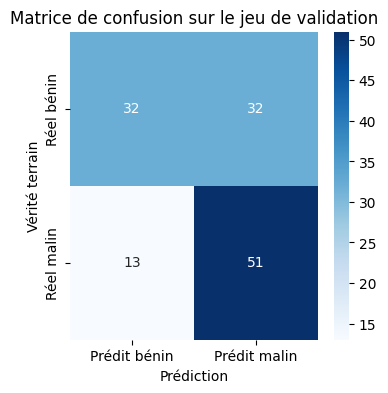

Vrais négatifs (TN)  : 32 (bénins bien classés)
Faux positifs (FP)   : 32 (bénins prédits comme malins)
Faux négatifs (FN)   : 13 (malins prédits comme bénins)
Vrais positifs (TP)  : 51 (malins bien classés)

Recall (sensibilité) de la classe maligne : 0.797

Interprétation (texte pour le rapport) :
- Sur le jeu de validation, le modèle a raté 13 cas malins (faux négatifs) sur 64 malins au total, soit une sensibilité d'environ 79.7%.
- Un faux négatif correspond à une tumeur réellement maligne prédite comme bénigne. En pratique clinique, c'est le cas le plus problématique car il peut retarder le diagnostic et la prise en charge.
- Il est souvent préférable d'accepter davantage de faux positifs (examens supplémentaires chez des patientes saines) pour réduire au maximum les faux négatifs, même si cela baisse légèrement la précision.

Rapport de classification détaillé :
              precision    recall  f1-score   support

       Bénin       0.71      0.50      0.59        64
       Mal

In [25]:
model.eval()
all_labels = []
all_preds = []
all_probs = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        logits = model(images)
        probs = torch.sigmoid(logits)
        preds = (probs >= 0.5).float()

        all_labels.extend(labels.cpu().numpy().tolist())
        all_probs.extend(probs.cpu().numpy().tolist())
        all_preds.extend(preds.cpu().numpy().tolist())

# 1. Matrice de confusion (0 = bénin, 1 = malin)
cm = confusion_matrix(all_labels, all_preds)
print("Matrice de confusion (val) :")
print(cm)

plt.figure(figsize=(4,4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Prédit bénin", "Prédit malin"],
    yticklabels=["Réel bénin", "Réel malin"]
)
plt.xlabel("Prédiction")
plt.ylabel("Vérité terrain")
plt.title("Matrice de confusion sur le jeu de validation")
plt.show()

# 2. Faux négatifs et recall de la classe maligne
if cm.shape == (2, 2):
    tn, fp, fn, tp = cm.ravel()
    print(f"Vrais négatifs (TN)  : {tn} (bénins bien classés)")
    print(f"Faux positifs (FP)   : {fp} (bénins prédits comme malins)")
    print(f"Faux négatifs (FN)   : {fn} (malins prédits comme bénins)")
    print(f"Vrais positifs (TP)  : {tp} (malins bien classés)")

    recall_malignant = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    print(f"\nRecall (sensibilité) de la classe maligne : {recall_malignant:.3f}")

    print("\nInterprétation (texte pour le rapport) :")
    print(
        f"- Sur le jeu de validation, le modèle a raté {fn} cas malins "
        f"(faux négatifs) sur {tp + fn} malins au total, soit une sensibilité "
        f"d'environ {recall_malignant:.1%}.\n"
        f"- Un faux négatif correspond à une tumeur réellement maligne "
        f"prédite comme bénigne. En pratique clinique, c'est le cas le plus "
        f"problématique car il peut retarder le diagnostic et la prise en charge.\n"
        f"- Il est souvent préférable d'accepter davantage de faux positifs "
        f"(examens supplémentaires chez des patientes saines) pour réduire "
        f"au maximum les faux négatifs, même si cela baisse légèrement la précision."
    )

# 3. Rapport détaillé (optionnel)
print("\nRapport de classification détaillé :")
print(classification_report(all_labels, all_preds, target_names=["Bénin", "Malin"]))

## 11. À retenir

- **Ne plus utiliser** `get_data()` qui ouvre toutes les images avant le training.
- **Ne plus faire** `print(get_data()[0])`, ça relance tout le chargement et bloque vite.
- Le bon flux est: `CSV -> meta_df -> Dataset -> DataLoader -> train`.
- Pour accélérer encore: diminuer la taille d'image, utiliser un sous-ensemble, puis passer à GPU si disponible.
